# FLEXIMOD cement market result quick analysis

Small notebook for checking market electricity procurement and market cost/revenue components for cement plant results. Companion to `steel_results_cost_energy_export.ipynb`.

Expected result files in `RESULTS_DIR`:

- `market_ledger.csv` preferred for market positions and settlement values
- `dispatch_results.csv` used as fallback
- `summary_indicators.csv` optional

## 1. Select the result folder

Set `RESULTS_ROOT` to the directory containing all cement-result folders and choose one `SELECTED_RESULT_FOLDER` for the individual-case charts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_ROOT = Path("/root/FLEXIMOD/data/output")
# Change only this folder name to analyse another individual case.
SELECTED_RESULT_FOLDER = "aktuellepolitiken_2030_R1_electrified_cement_rule_based"
RESULTS_DIR = RESULTS_ROOT / SELECTED_RESULT_FOLDER
ANALYSIS_SCENARIO_PREFIXES = (
    "technologiemix_",
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
    "fokusstrom_",
    "fokusH2_",
)

RESULTS_DIR.resolve()

PosixPath('/root/FLEXIMOD/data/output/aktuellepolitiken_2030_R1_electrified_cement_rule_based')

## 2. Load result files

Load the market ledger, dispatch results, and summary indicators when they are available, then preview the selected case.

In [2]:
def read_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path.name}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    print(f"Loaded {path.name}: {len(df):,} rows, {len(df.columns):,} columns")
    return df


market = read_optional_csv(RESULTS_DIR / "market_ledger.csv")
dispatch = read_optional_csv(RESULTS_DIR / "dispatch_results.csv")
summary = read_optional_csv(RESULTS_DIR / "summary_indicators.csv")

market.head() if not market.empty else dispatch.head()

Missing: market_ledger.csv
Missing: dispatch_results.csv
Missing: summary_indicators.csv


""


## 3. Define analysis helpers

Define reusable functions for safe numeric conversion, column discovery, aggregation, and quantity-price calculations.

In [3]:
def numeric_series(df: pd.DataFrame, column: str, default: float = 0.0) -> pd.Series:
    if df.empty or column not in df.columns:
        return pd.Series([default], dtype=float)
    return pd.to_numeric(df[column], errors="coerce").fillna(default)


def column_sum(df: pd.DataFrame, column: str) -> float:
    return float(numeric_series(df, column).sum())


def first_existing(df: pd.DataFrame, columns: list[str]) -> str | None:
    for column in columns:
        if not df.empty and column in df.columns:
            return column
    return None


def weighted_value(df: pd.DataFrame, quantity_col: str, price_col: str) -> float:
    if df.empty or quantity_col not in df.columns or price_col not in df.columns:
        return 0.0
    quantity = pd.to_numeric(df[quantity_col], errors="coerce").fillna(0.0)
    price = pd.to_numeric(df[price_col], errors="coerce").fillna(0.0)
    return float((quantity * price).sum())

## Electricity procurement by market

This plot answers: how much electricity came from day-ahead, intraday buy/sell, and activated aFRR down energy?

In [4]:
source = market if not market.empty else dispatch

procurement = {
    "Day-ahead procurement": column_sum(
        source,
        first_existing(source, ["day_ahead_position_MWh_el", "DA_position_MWh"]) or "",
    ),
    "Intraday buy": column_sum(
        source,
        first_existing(source, ["intraday_buy_MWh_el", "IDC_buy_MWh"]) or "",
    ),
    "Intraday sell": -column_sum(
        source,
        first_existing(source, ["intraday_sell_MWh_el", "IDC_sell_MWh"]) or "",
    ),
    "aFRR activated energy": column_sum(
        source,
        first_existing(source, ["afrr_energy_activated_MWh_el", "afrr_energy_activated_MWh"]) or "",
    ),
}

procurement_df = pd.DataFrame(
    {"market": procurement.keys(), "electricity_MWh": procurement.values()}
).query("electricity_MWh != 0")

display(procurement_df)

if procurement_df.empty:
    print("No electricity procurement or aFRR activation is recorded in these results.")
else:
    ax = procurement_df.plot.bar(
        x="market",
        y="electricity_MWh",
        legend=False,
        color=["#4C78A8", "#72B7B2", "#F58518", "#B279A2"][: len(procurement_df)],
        figsize=(8, 4),
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Electricity [MWh_el]")
    ax.set_xlabel("")
    ax.set_title("Electricity procurement by market")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

,market,electricity_MWh


No electricity procurement or aFRR activation is recorded in these results.


## Market cost / revenue waterfall

Positive bars increase cost. Negative bars are revenues or sales that reduce net market cost.

The waterfall focuses on market-facing electricity settlement, not material input costs such as raw meal, fuel, or CO2 allowances.

,component,value_EUR
0,Net market cost,0.0


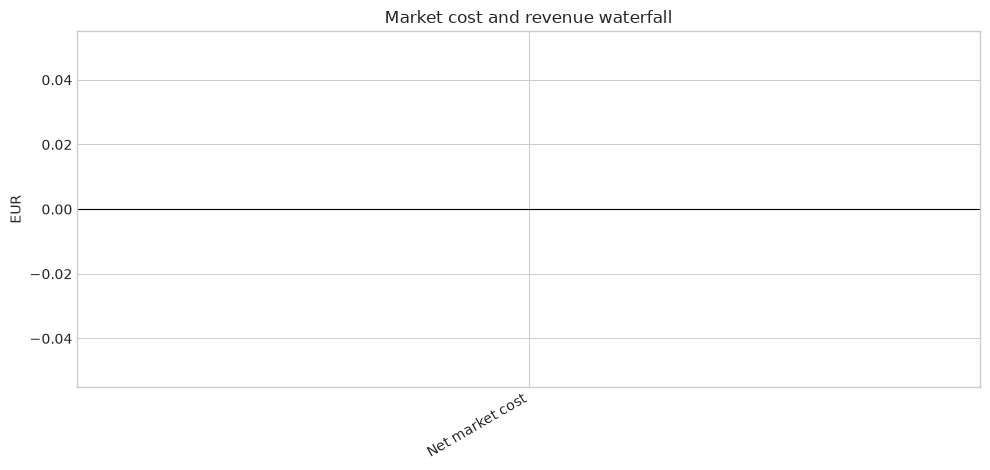

In [5]:
if not market.empty:
    components = {
        "Day-ahead electricity": weighted_value(
            market,
            "day_ahead_position_MWh_el",
            "day_ahead_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday buy": weighted_value(
            market,
            "intraday_buy_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday sell": -weighted_value(
            market,
            "intraday_sell_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR energy settlement": weighted_value(
            market,
            "afrr_energy_activated_MWh_el",
            "afrr_energy_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR capacity revenue": -column_sum(market, "afrr_capacity_revenue_EUR"),
    }
else:
    components = {
        "Electricity market cost": column_sum(dispatch, "electricity_market_cost_EUR"),
        "Additional electricity charges": column_sum(
            dispatch, "additional_electricity_charges_cost_EUR"
        ),
        "aFRR capacity revenue": -column_sum(dispatch, "afrr_capacity_revenue_EUR"),
    }

waterfall_df = pd.DataFrame(
    {"component": components.keys(), "value_EUR": components.values()}
).query("value_EUR != 0")
waterfall_df.loc[len(waterfall_df)] = ["Net market cost", waterfall_df["value_EUR"].sum()]

display(waterfall_df)

running = waterfall_df["value_EUR"].iloc[:-1].cumsum().shift(fill_value=0.0)
values = waterfall_df["value_EUR"].iloc[:-1]
labels = waterfall_df["component"].iloc[:-1].tolist()
net = waterfall_df["value_EUR"].iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#D95F02" if value >= 0 else "#1B9E77" for value in values]
ax.bar(labels, values, bottom=running, color=colors)
ax.bar(["Net market cost"], [net], color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("EUR")
ax.set_title("Market cost and revenue waterfall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Optional: per-plant market procurement

Useful when the output contains several plants/routes.

In [6]:
if not market.empty and "plant_name" in market.columns:
    per_plant = market.groupby("plant_name", dropna=False).agg(
        day_ahead_MWh=("day_ahead_position_MWh_el", "sum"),
        afrr_activated_MWh=("afrr_energy_activated_MWh_el", "sum"),
        capacity_revenue_EUR=("afrr_capacity_revenue_EUR", "sum"),
    )
    display(per_plant)
    per_plant[["day_ahead_MWh", "afrr_activated_MWh"]].plot.bar(
        stacked=True,
        figsize=(10, 4),
        color=["#4C78A8", "#B279A2"],
    )
    plt.ylabel("Electricity [MWh_el]")
    plt.title("Electricity procurement by plant")
    plt.tight_layout()
else:
    print("No market_ledger.csv with plant_name column available.")

No market_ledger.csv with plant_name column available.


## Net cost by plant

Scans every use-case output folder under the configured `RESULTS_ROOT`, calculates net cost for every plant, and adds a portfolio total. It uses the most complete available output: net operating cost including grid fees, net operating cost, total net operating cost, or total variable cost.

In [7]:
def summary_value(row: pd.Series, column: str) -> float | None:
    value = pd.to_numeric(pd.Series([row.get(column)]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def net_cost_from_summary(summary: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in summary.iterrows():
        plant_name = row.get("plant_name", "unnamed plant")
        gross_cost = summary_value(row, "gross_operating_cost_EUR")
        variable_cost = summary_value(row, "total_variable_cost_EUR")
        net_incl_grid_fees = summary_value(row, "net_operating_cost_incl_grid_fees_EUR")
        net_cost = summary_value(row, "net_operating_cost_EUR")
        total_net_cost = summary_value(row, "total_net_operating_cost_EUR")

        # Cement cost-minimisation has no market settlement columns: its
        # total_variable_cost_EUR is the complete process cost. Do not use
        # the zero-filled net-operating-cost placeholder in that case.
        if gross_cost is not None and abs(gross_cost) > 1e-9:
            if net_incl_grid_fees is not None:
                cost, basis = net_incl_grid_fees, "net operating cost incl. grid fees"
            elif net_cost is not None:
                cost, basis = net_cost, "net operating cost"
            else:
                cost, basis = gross_cost, "gross operating cost"
        elif total_net_cost is not None:
            cost, basis = total_net_cost, "total net operating cost"
        elif variable_cost is not None:
            cost, basis = variable_cost, "total variable cost"
        else:
            print(f"Skipping {plant_name}: no recognised cost column in summary_indicators.csv.")
            continue

        records.append({"plant_name": plant_name, "net_cost_EUR": cost, "cost_basis": basis})
    return pd.DataFrame(records)


OUTPUT_ROOT = RESULTS_ROOT.resolve()
summary_paths = sorted(
    path
    for path in OUTPUT_ROOT.glob("*/summary_indicators.csv")
    if path.parent.name.startswith(ANALYSIS_SCENARIO_PREFIXES)
)

if not summary_paths:
    print(f"No summary_indicators.csv files found under {OUTPUT_ROOT}.")
else:
    cost_frames = []
    for summary_path in summary_paths:
        case_summary = pd.read_csv(summary_path)
        if "plant_name" not in case_summary.columns:
            print(f"Skipping {summary_path.parent.name}: no plant_name column.")
            continue

        case_costs = net_cost_from_summary(case_summary)
        if case_costs.empty:
            print(f"Skipping {summary_path.parent.name}: no recognised cost values.")
            continue

        case_costs.insert(0, "output_folder", summary_path.parent.name)
        cost_frames.append(case_costs)

    if not cost_frames:
        print("No recognised net-cost values were found in the output folders.")
    else:
        net_cost_by_plant = pd.concat(cost_frames, ignore_index=True)
        portfolio_total = net_cost_by_plant["net_cost_EUR"].sum()
        net_cost_by_plant.loc[len(net_cost_by_plant)] = {
            "output_folder": "All output folders",
            "plant_name": "All plants",
            "net_cost_EUR": portfolio_total,
            "cost_basis": "portfolio total",
        }
        net_cost_by_plant["net_cost_MEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000
        net_cost_by_plant["net_cost_BEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000_000
        display(
            net_cost_by_plant.style.format(
                {
                    "net_cost_EUR": "{:,.2f}",
                    "net_cost_MEUR": "{:,.2f}",
                    "net_cost_BEUR": "{:,.3f}",
                }
            )
        )

No summary_indicators.csv files found under /root/FLEXIMOD/data/output.


## Temporary CO2, labour, maintenance, and network-cost correction

Scan the six cement scenario families and calculate annual net cost including labour at **38 EUR/t clinker**, maintenance at **2.37 EUR/t clinker**, fuel-network capacity tariffs, and the electricity-grid capacity tariff. The labour and maintenance rates are reused from the steel analysis as a placeholder pending cement-specific figures. The electricity tariff is **11.39 EUR/kW/year below 2,500 full-load hours** and **53.06 EUR/kW/year from 2,500 hours**. At 7,000, 7,500, and 8,000 hours, respectively, the payable tariff is reduced to **20%, 15%, and 10%** of the published rate. The temporary CO2 addition is currently disabled for all six families because they already include corrected fuel-emission factors and CO2 cost. This analysis does not modify simulation results.

In [8]:
from pathlib import Path

import pandas as pd
from IPython.display import display

# Annual fixed-cost additions. CO2 is already included in the simulated net
# operating costs for every scenario analysed in this notebook.
CO2_COST_ALREADY_INCLUDED_PREFIXES = (
    "technologiemix_",
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
    "fokusH2_",
    "fokusstrom_",
)
CO2_ANALYSIS_SCENARIO_PREFIXES = (
    *CO2_COST_ALREADY_INCLUDED_PREFIXES,
)
# EUR per tonne clinker; reusing the steel-analysis rates as a placeholder
# pending cement-specific labour and maintenance figures.
LABOUR_COST_EUR_PER_T = 38.0
MAINTENANCE_COST_EUR_PER_T = 2.37
HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A = 25.0
NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A = 7.06
ELECTRICITY_GRID_TARIFF_LOW_EUR_PER_KW_A = 11.39
ELECTRICITY_GRID_TARIFF_HIGH_EUR_PER_KW_A = 53.06


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the FLEXIMOD project root from the current working directory."
    )


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = RESULTS_ROOT.resolve()
INPUT_ROOT = PROJECT_ROOT / "data" / "input"
ASSUME_OUTPUT_ROOT = RESULTS_ROOT.parent.parent / "Assume" / "Output"


def input_case_for_output(output_folder: Path) -> Path | None:
    candidates = [
        case_dir
        for case_dir in INPUT_ROOT.iterdir()
        if case_dir.is_dir() and output_folder.name.startswith(f"{case_dir.name}_")
    ]
    return max(candidates, key=lambda path: len(path.name), default=None)


def temporary_summary_value(row: pd.Series, column: str) -> float | None:
    value = pd.to_numeric(pd.Series([row.get(column)]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def temporary_net_cost_from_summary(case_summary: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in case_summary.iterrows():
        plant_name = row.get("plant_name", "unnamed plant")
        gross_cost = temporary_summary_value(row, "gross_operating_cost_EUR")
        variable_cost = temporary_summary_value(row, "total_variable_cost_EUR")
        net_cost = temporary_summary_value(row, "net_operating_cost_EUR")
        total_net_cost = temporary_summary_value(row, "total_net_operating_cost_EUR")
        afrr_capacity_revenue = (
            temporary_summary_value(row, "total_afrr_capacity_revenue_EUR") or 0.0
        )
        day_ahead_procured_MWh = temporary_summary_value(row, "total_DA_electricity_MWh") or 0.0
        afrr_energy_procured_MWh = (
            temporary_summary_value(row, "total_afrr_energy_activated_MWh") or 0.0
        )
        electricity_market_cost = (
            temporary_summary_value(row, "total_electricity_market_cost_EUR") or 0.0
        )
        additional_electricity_charges = (
            temporary_summary_value(row, "total_additional_electricity_charges_cost_EUR") or 0.0
        )
        total_co2_emissions_t = temporary_summary_value(row, "total_co2_emissions_t") or 0.0

        if gross_cost is not None and abs(gross_cost) > 1e-9:
            # Start before the ex-post grid-capacity settlement because this
            # cell calculates that capacity charge explicitly below.
            cost = net_cost if net_cost is not None else gross_cost
            gross_basis_cost = gross_cost
        elif total_net_cost is not None:
            cost = total_net_cost
            gross_basis_cost = total_net_cost + afrr_capacity_revenue
        elif variable_cost is not None:
            cost = variable_cost
            gross_basis_cost = variable_cost + afrr_capacity_revenue
        else:
            continue

        # gross_operating_cost_EUR = process cost + electricity market cost (day-ahead
        # + aFRR energy settlement) + additional electricity charges, by construction
        # in the simulation (CementPlant.gross_operating_cost / the rule-based strategy's
        # equivalent). Isolating the process share turns that one opaque total into a
        # named component so every euro of cost is attributed somewhere below.
        process_cost = gross_basis_cost - electricity_market_cost - additional_electricity_charges

        records.append(
            {
                "plant_name": plant_name,
                "original_net_cost_EUR": cost,
                "process_cost_EUR": process_cost,
                "electricity_market_cost_EUR": electricity_market_cost,
                "additional_electricity_charges_cost_EUR": additional_electricity_charges,
                "afrr_capacity_revenue_EUR": afrr_capacity_revenue,
                "day_ahead_electricity_procured_MWh": day_ahead_procured_MWh,
                "afrr_energy_procured_MWh": afrr_energy_procured_MWh,
                "total_co2_emissions_t": total_co2_emissions_t,
            }
        )
    return pd.DataFrame(records)


original_cost_frames = []
for summary_path in sorted(OUTPUT_ROOT.glob("*/summary_indicators.csv")):
    case_costs = temporary_net_cost_from_summary(pd.read_csv(summary_path))
    if case_costs.empty:
        continue
    case_costs.insert(0, "output_folder", summary_path.parent.name)
    original_cost_frames.append(case_costs)

original_costs = (
    pd.concat(original_cost_frames, ignore_index=True)
    if original_cost_frames
    else pd.DataFrame(
        columns=[
            "output_folder",
            "plant_name",
            "original_net_cost_EUR",
            "process_cost_EUR",
            "electricity_market_cost_EUR",
            "additional_electricity_charges_cost_EUR",
            "afrr_capacity_revenue_EUR",
            "day_ahead_electricity_procured_MWh",
            "afrr_energy_procured_MWh",
            "total_co2_emissions_t",
        ]
    )
)

correction_records = []
for output_folder in sorted(
    path
    for path in OUTPUT_ROOT.iterdir()
    if path.is_dir() and path.name.startswith(CO2_COST_ALREADY_INCLUDED_PREFIXES)
):
    dispatch_path = output_folder / "dispatch_results.csv"
    input_case = input_case_for_output(output_folder)
    if not dispatch_path.exists():
        continue
    electrolyser_plants: set[str] = set()
    if input_case is not None:
        plants_path = input_case / "plants.csv"
        if plants_path.exists():
            plant_technologies = pd.read_csv(plants_path, usecols=["name", "technology"])
            electrolyser_plants.update(
                plant_technologies.loc[
                    plant_technologies["technology"]
                    .astype(str)
                    .str.lower()
                    .eq("electrolyser"),
                    "name",
                ].astype(str)
            )

    dispatch_columns = [
        "datetime",
        "plant_name",
        "cement_route",
        "clinker_output_t",
        "total_electricity_consumption_MWh",
        "coal_consumption_MWh",
        "natural_gas_consumption_MWh",
        "hydrogen_consumption_MWh",
    ]
    # engine="pyarrow": these dispatch files cover 32 plants x a full year at
    # 15-min resolution (~1M+ rows, ~1 GB each); the pyarrow reader is
    # several times faster than the default C engine at this size.
    try:
        case_dispatch = pd.read_csv(
            dispatch_path, usecols=dispatch_columns, engine="pyarrow"
        )
    except (OSError, ValueError, pd.errors.ParserError) as exc:
        print(f"Skipping {output_folder.name}: {exc}")
        continue
    dispatch_plant_names = case_dispatch["plant_name"].astype(str)
    electrolyser_plants.update(
        dispatch_plant_names[dispatch_plant_names.str.contains("_electrolyser", case=False)]
    )

    case_dispatch["datetime"] = pd.to_datetime(case_dispatch["datetime"], errors="raise")
    unique_timestamps = case_dispatch["datetime"].drop_duplicates().sort_values()
    positive_timestep_deltas = unique_timestamps.diff().dropna().dt.total_seconds() / 3600.0
    positive_timestep_deltas = positive_timestep_deltas[positive_timestep_deltas > 0]
    if positive_timestep_deltas.empty:
        raise ValueError(f"{output_folder.name}: cannot infer the dispatch timestep")
    timestep_hours = float(positive_timestep_deltas.median())
    corrected = case_dispatch.copy()

    natural_gas = pd.to_numeric(corrected["natural_gas_consumption_MWh"], errors="coerce").fillna(
        0.0
    )
    corrected["clinker_output_t"] = pd.to_numeric(
        corrected["clinker_output_t"], errors="coerce"
    ).fillna(0.0)
    corrected["hydrogen_consumption_MWh"] = pd.to_numeric(
        corrected["hydrogen_consumption_MWh"], errors="coerce"
    ).fillna(0.0)
    corrected["total_electricity_consumption_MWh"] = pd.to_numeric(
        corrected["total_electricity_consumption_MWh"], errors="coerce"
    ).fillna(0.0)

    # All selected scenarios already include their CO2 costs in the simulation.
    corrected["temporary_co2_correction_applied"] = False
    corrected["temporary_missing_co2_emissions_t"] = 0.0
    corrected["temporary_missing_co2_cost_EUR"] = 0.0
    corrected["labour_cost_EUR"] = corrected["clinker_output_t"] * LABOUR_COST_EUR_PER_T
    corrected["maintenance_cost_EUR"] = corrected["clinker_output_t"] * MAINTENANCE_COST_EUR_PER_T
    corrected["uses_external_hydrogen"] = corrected["hydrogen_consumption_MWh"].gt(
        0.0
    ) & ~corrected["plant_name"].astype(str).isin(electrolyser_plants)
    corrected["external_hydrogen_withdrawal_MW"] = (
        corrected["hydrogen_consumption_MWh"] / timestep_hours
    ).where(corrected["uses_external_hydrogen"], 0.0)
    corrected["natural_gas_withdrawal_MW"] = natural_gas / timestep_hours
    corrected["electricity_withdrawal_MW"] = (
        corrected["total_electricity_consumption_MWh"] / timestep_hours
    )

    per_plant_correction = corrected.groupby(
        ["plant_name", "cement_route"], as_index=False, dropna=False
    ).agg(
        temporary_co2_correction_applied=("temporary_co2_correction_applied", "first"),
        annual_clinker_output_t=("clinker_output_t", "sum"),
        temporary_missing_co2_emissions_t=(
            "temporary_missing_co2_emissions_t",
            "sum",
        ),
        temporary_missing_co2_cost_EUR=("temporary_missing_co2_cost_EUR", "sum"),
        labour_cost_EUR=("labour_cost_EUR", "sum"),
        maintenance_cost_EUR=("maintenance_cost_EUR", "sum"),
        external_hydrogen_peak_MW=("external_hydrogen_withdrawal_MW", "max"),
        natural_gas_peak_MW=("natural_gas_withdrawal_MW", "max"),
        annual_electricity_demand_MWh=("total_electricity_consumption_MWh", "sum"),
        electricity_peak_MW=("electricity_withdrawal_MW", "max"),
    )
    per_plant_correction["hydrogen_network_tariff_EUR_per_kW_a"] = (
        HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["annual_hydrogen_network_cost_EUR"] = (
        per_plant_correction["external_hydrogen_peak_MW"]
        * 1_000.0
        * HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["natural_gas_network_tariff_EUR_per_kW_a"] = (
        NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["annual_natural_gas_network_cost_EUR"] = (
        per_plant_correction["natural_gas_peak_MW"]
        * 1_000.0
        * NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["electricity_full_load_hours"] = (
        per_plant_correction["annual_electricity_demand_MWh"]
        .div(
            per_plant_correction["electricity_peak_MW"].where(
                per_plant_correction["electricity_peak_MW"].gt(0.0)
            )
        )
        .fillna(0.0)
    )
    per_plant_correction["electricity_grid_published_tariff_EUR_per_kW_a"] = (
        ELECTRICITY_GRID_TARIFF_LOW_EUR_PER_KW_A
    )
    high_grid_tier = per_plant_correction["electricity_full_load_hours"].ge(2_500.0)
    per_plant_correction.loc[high_grid_tier, "electricity_grid_published_tariff_EUR_per_kW_a"] = (
        ELECTRICITY_GRID_TARIFF_HIGH_EUR_PER_KW_A
    )
    per_plant_correction["electricity_grid_payable_share"] = 1.0
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(7_000.0),
        "electricity_grid_payable_share",
    ] = 0.20
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(7_500.0),
        "electricity_grid_payable_share",
    ] = 0.15
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(8_000.0),
        "electricity_grid_payable_share",
    ] = 0.10
    per_plant_correction["electricity_grid_effective_tariff_EUR_per_kW_a"] = (
        per_plant_correction["electricity_grid_published_tariff_EUR_per_kW_a"]
        * per_plant_correction["electricity_grid_payable_share"]
    )
    per_plant_correction["annual_electricity_grid_capacity_cost_EUR"] = (
        per_plant_correction["electricity_peak_MW"]
        * 1_000.0
        * per_plant_correction["electricity_grid_effective_tariff_EUR_per_kW_a"]
    )
    per_plant_correction.insert(0, "output_folder", output_folder.name)
    correction_records.append(per_plant_correction)

if not correction_records:
    print("No completed cement dispatch outputs were found for annual-cost analysis.")
else:
    temporary_co2_correction = pd.concat(correction_records, ignore_index=True)
    adjusted_net_cost_by_plant = original_costs.merge(
        temporary_co2_correction,
        on=["output_folder", "plant_name"],
        how="inner",
        validate="one_to_one",
    )

    # Total cost per component: every euro of cost is attributed to a named
    # column, so the sum below reconciles exactly to the two headline figures.
    adjusted_net_cost_by_plant["total_cost_excl_revenue_EUR"] = (
        adjusted_net_cost_by_plant["process_cost_EUR"]
        + adjusted_net_cost_by_plant["electricity_market_cost_EUR"]
        + adjusted_net_cost_by_plant["additional_electricity_charges_cost_EUR"]
        + adjusted_net_cost_by_plant["temporary_missing_co2_cost_EUR"]
        + adjusted_net_cost_by_plant["labour_cost_EUR"]
        + adjusted_net_cost_by_plant["maintenance_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_hydrogen_network_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_natural_gas_network_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_electricity_grid_capacity_cost_EUR"]
    )
    adjusted_net_cost_by_plant["net_cost_incl_revenue_EUR"] = (
        adjusted_net_cost_by_plant["total_cost_excl_revenue_EUR"]
        - adjusted_net_cost_by_plant["afrr_capacity_revenue_EUR"]
    )
    adjusted_net_cost_by_plant["total_cost_excl_revenue_MEUR"] = (
        adjusted_net_cost_by_plant["total_cost_excl_revenue_EUR"] / 1_000_000
    )
    adjusted_net_cost_by_plant["total_cost_excl_revenue_BEUR"] = (
        adjusted_net_cost_by_plant["total_cost_excl_revenue_EUR"] / 1_000_000_000
    )
    adjusted_net_cost_by_plant["net_cost_incl_revenue_MEUR"] = (
        adjusted_net_cost_by_plant["net_cost_incl_revenue_EUR"] / 1_000_000
    )
    adjusted_net_cost_by_plant["net_cost_incl_revenue_BEUR"] = (
        adjusted_net_cost_by_plant["net_cost_incl_revenue_EUR"] / 1_000_000_000
    )

    total_columns = [
        "original_net_cost_EUR",
        "process_cost_EUR",
        "electricity_market_cost_EUR",
        "additional_electricity_charges_cost_EUR",
        "afrr_capacity_revenue_EUR",
        "day_ahead_electricity_procured_MWh",
        "afrr_energy_procured_MWh",
        "total_co2_emissions_t",
        "annual_clinker_output_t",
        "temporary_missing_co2_emissions_t",
        "temporary_missing_co2_cost_EUR",
        "labour_cost_EUR",
        "maintenance_cost_EUR",
        "external_hydrogen_peak_MW",
        "annual_hydrogen_network_cost_EUR",
        "natural_gas_peak_MW",
        "annual_natural_gas_network_cost_EUR",
        "annual_electricity_demand_MWh",
        "electricity_peak_MW",
        "annual_electricity_grid_capacity_cost_EUR",
        "total_cost_excl_revenue_EUR",
        "total_cost_excl_revenue_MEUR",
        "total_cost_excl_revenue_BEUR",
        "net_cost_incl_revenue_EUR",
        "net_cost_incl_revenue_MEUR",
        "net_cost_incl_revenue_BEUR",
    ]
    total_row = {
        "output_folder": "All output folders",
        "plant_name": "All plants",
        "cement_route": "portfolio total",
        "hydrogen_network_tariff_EUR_per_kW_a": HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A,
        "natural_gas_network_tariff_EUR_per_kW_a": NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A,
        "electricity_full_load_hours": float("nan"),
        "electricity_grid_published_tariff_EUR_per_kW_a": float("nan"),
        "electricity_grid_payable_share": float("nan"),
        "electricity_grid_effective_tariff_EUR_per_kW_a": float("nan"),
        **{column: adjusted_net_cost_by_plant[column].sum() for column in total_columns},
    }
    adjusted_net_cost_by_plant.loc[len(adjusted_net_cost_by_plant)] = total_row
    display(
        adjusted_net_cost_by_plant.style.format(
            {
                "original_net_cost_EUR": "{:,.2f}",
                "process_cost_EUR": "{:,.2f}",
                "electricity_market_cost_EUR": "{:,.2f}",
                "additional_electricity_charges_cost_EUR": "{:,.2f}",
                "afrr_capacity_revenue_EUR": "{:,.2f}",
                "day_ahead_electricity_procured_MWh": "{:,.2f}",
                "afrr_energy_procured_MWh": "{:,.2f}",
                "total_co2_emissions_t": "{:,.2f}",
                "annual_clinker_output_t": "{:,.2f}",
                "temporary_missing_co2_emissions_t": "{:,.2f}",
                "temporary_missing_co2_cost_EUR": "{:,.2f}",
                "labour_cost_EUR": "{:,.2f}",
                "maintenance_cost_EUR": "{:,.2f}",
                "external_hydrogen_peak_MW": "{:,.3f}",
                "hydrogen_network_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_hydrogen_network_cost_EUR": "{:,.2f}",
                "natural_gas_peak_MW": "{:,.3f}",
                "natural_gas_network_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_natural_gas_network_cost_EUR": "{:,.2f}",
                "annual_electricity_demand_MWh": "{:,.2f}",
                "electricity_peak_MW": "{:,.3f}",
                "electricity_full_load_hours": "{:,.1f}",
                "electricity_grid_published_tariff_EUR_per_kW_a": "{:,.2f}",
                "electricity_grid_payable_share": "{:.0%}",
                "electricity_grid_effective_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_electricity_grid_capacity_cost_EUR": "{:,.2f}",
                "total_cost_excl_revenue_EUR": "{:,.2f}",
                "total_cost_excl_revenue_MEUR": "{:,.2f}",
                "total_cost_excl_revenue_BEUR": "{:,.3f}",
                "net_cost_incl_revenue_EUR": "{:,.2f}",
                "net_cost_incl_revenue_MEUR": "{:,.2f}",
                "net_cost_incl_revenue_BEUR": "{:,.3f}",
            }
        )
    )

No completed cement dispatch outputs were found for annual-cost analysis.


## Energy demand by carrier and plant

Scan every completed output folder and report electricity, coal, natural-gas, and hydrogen demand for each plant in MWh and GWh, including carrier shares and total final energy.

In [9]:
# Energy demand by carrier, and CO2 emissions by component, for every plant in
# every completed output folder. Both piggyback on the same dispatch_results.csv
# read (these files are ~1 GB / 32 plants each, so a second full pass just for
# CO2 would roughly double this cell's runtime for no reason).
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_fleximod_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FLEXIMOD project root.")


PROJECT_ROOT_ENERGY = find_fleximod_root()
OUTPUT_ROOT_ENERGY = RESULTS_ROOT.resolve()

# Authoritative aggregate columns and their physical carrier units.
CARRIER_COLUMNS = {
    "Electricity": ("total_electricity_consumption_MWh", "MWh_el"),
    "Coal": ("coal_consumption_MWh", "MWh_fuel"),
    "Natural gas": ("natural_gas_consumption_MWh", "MWh_fuel"),
    "Hydrogen": ("hydrogen_consumption_MWh", "MWh_H2"),
}

# Not every route has every column: CCS routes have the capture/residual set,
# fuel-blend routes have the biogenic/fossil/RDF split, and oxy-fuel/leilac
# calciners add a separated-stream pair. All are collected wherever present;
# a route lacking a given column simply gets NaN there, not zero, so "not
# modelled here" stays visually distinct from "modelled and zero".
CO2_COLUMNS = [
    "gross_co2_emissions_t",
    "simple_calciner_process_co2_emissions_t",
    "simple_calciner_separated_process_co2_t",
    "co2_separated_t",
    "ccs_co2_input_t",
    "ccs_co2_priced_input_t",
    "co2_captured_t",
    "co2_priced_captured_t",
    "co2_unpriced_captured_t",
    "co2_residual_t",
    "ccs_co2_priced_residual_t",
    "co2_priced_emissions_t",
    "co2_priced_t",
    "co2_biogenic_t",
    "co2_fossil_t",
    "co2_rdf_t",
    "co2_rdf_biogenic_t",
    "co2_rdf_fossil_t",
    "co2_emissions_t",
]

ANALYSIS_SCENARIO_PREFIXES_ENERGY = (
    "technologiemix_",
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
    "fokusstrom_",
    "fokusH2_",
)

energy_records = []
co2_records = []
dispatch_files = sorted(
    path
    for path in OUTPUT_ROOT_ENERGY.glob("*/dispatch_results.csv")
    if path.parent.name.startswith(ANALYSIS_SCENARIO_PREFIXES_ENERGY)
)
unreadable_dispatch_files = []

for dispatch_file in dispatch_files:
    try:
        available_columns = set(pd.read_csv(dispatch_file, nrows=0).columns)
    except (OSError, pd.errors.ParserError) as exc:
        unreadable_dispatch_files.append((dispatch_file, exc))
        print(f"Skipping unreadable dispatch file: {dispatch_file} ({exc})")
        continue
    carrier_columns = {
        carrier: (column, unit)
        for carrier, (column, unit) in CARRIER_COLUMNS.items()
        if column in available_columns
    }
    co2_columns_present = [column for column in CO2_COLUMNS if column in available_columns]
    if "plant_name" not in available_columns or not (carrier_columns or co2_columns_present):
        continue

    identity_columns = ["plant_name"]
    for optional_column in ("plant_type", "cement_route"):
        if optional_column in available_columns:
            identity_columns.append(optional_column)

    usecols = (
        identity_columns
        + [column for column, _ in carrier_columns.values()]
        + co2_columns_present
    )
    # engine="pyarrow": these dispatch files cover 32 plants x a full year at
    # 15-min resolution (~1M+ rows, ~1 GB each); the pyarrow reader is
    # several times faster than the default C engine at this size.
    try:
        data = pd.read_csv(dispatch_file, usecols=usecols, engine="pyarrow")
    except (OSError, ValueError, pd.errors.ParserError) as exc:
        unreadable_dispatch_files.append((dispatch_file, exc))
        print(f"Skipping unreadable dispatch file: {dispatch_file} ({exc})")
        continue
    for column, _ in carrier_columns.values():
        data[column] = pd.to_numeric(data[column], errors="coerce").fillna(0.0)
    for column in co2_columns_present:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    # A single groupby-sum covers both energy and CO2 columns; sum() over a
    # column of all-NaN values (a column absent for this file) stays NaN,
    # which is what distinguishes "not modelled" from "modelled as zero".
    grouped = data.groupby(identity_columns, dropna=False, as_index=False).sum(
        numeric_only=True, min_count=1
    )
    for _, plant in grouped.iterrows():
        for carrier, (column, unit) in carrier_columns.items():
            energy_records.append(
                {
                    "output_folder": dispatch_file.parent.name,
                    "plant_name": plant["plant_name"],
                    "plant_type": plant.get("plant_type", ""),
                    "cement_route": plant.get("cement_route", ""),
                    "energy_carrier": carrier,
                    "carrier_unit": unit,
                    "energy_demand_MWh": float(plant[column]),
                }
            )
        if co2_columns_present:
            co2_row = {
                "output_folder": dispatch_file.parent.name,
                "plant_name": plant["plant_name"],
                "plant_type": plant.get("plant_type", ""),
                "cement_route": plant.get("cement_route", ""),
            }
            for column in co2_columns_present:
                co2_row[column] = float(plant[column]) if pd.notna(plant[column]) else float("nan")
            co2_records.append(co2_row)

if unreadable_dispatch_files:
    print(f"Skipped {len(unreadable_dispatch_files)} unreadable dispatch file(s).")

energy_demand_by_carrier = pd.DataFrame(energy_records)
co2_emissions_by_component = pd.DataFrame(co2_records)

if energy_demand_by_carrier.empty:
    print(
        f"No dispatch results containing supported energy-carrier columns found under {OUTPUT_ROOT_ENERGY}"
    )
else:
    energy_demand_by_carrier["energy_demand_GWh"] = (
        energy_demand_by_carrier["energy_demand_MWh"] / 1_000.0
    )
    plant_totals = energy_demand_by_carrier.groupby(["output_folder", "plant_name"], dropna=False)[
        "energy_demand_MWh"
    ].transform("sum")
    energy_demand_by_carrier["carrier_share_percent"] = (
        energy_demand_by_carrier["energy_demand_MWh"]
        .div(plant_totals.where(plant_totals.ne(0)))
        .mul(100.0)
        .fillna(0.0)
    )

    energy_demand_by_carrier = energy_demand_by_carrier.sort_values(
        ["output_folder", "plant_name", "energy_carrier"]
    ).reset_index(drop=True)

    print(
        f"Energy demand by carrier: {energy_demand_by_carrier['plant_name'].nunique()} unique plant name(s) "
        f"across {energy_demand_by_carrier['output_folder'].nunique()} completed output folder(s)."
    )
    display(
        energy_demand_by_carrier.style.format(
            {
                "energy_demand_MWh": "{:,.2f}",
                "energy_demand_GWh": "{:,.3f}",
                "carrier_share_percent": "{:,.2f}%",
            }
        )
    )

    # Compact plant-by-carrier view; values are GWh over the simulated period.
    energy_demand_pivot_GWh = (
        energy_demand_by_carrier.pivot_table(
            index=["output_folder", "plant_name", "cement_route"],
            columns="energy_carrier",
            values="energy_demand_GWh",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reset_index()
        .rename_axis(columns=None)
    )
    carrier_value_columns = [
        column for column in CARRIER_COLUMNS if column in energy_demand_pivot_GWh.columns
    ]
    energy_demand_pivot_GWh["Total final energy"] = energy_demand_pivot_GWh[
        carrier_value_columns
    ].sum(axis=1)
    display(
        energy_demand_pivot_GWh.style.format(
            {column: "{:,.3f}" for column in carrier_value_columns + ["Total final energy"]}
        )
    )

if co2_emissions_by_component.empty:
    print(f"No dispatch results containing CO2 columns found under {OUTPUT_ROOT_ENERGY}")
else:
    # Convenience metrics where the inputs exist for a given route.
    if {"co2_captured_t", "ccs_co2_input_t"}.issubset(co2_emissions_by_component.columns):
        co2_emissions_by_component["ccs_capture_rate_percent"] = (
            co2_emissions_by_component["co2_captured_t"]
            .div(co2_emissions_by_component["ccs_co2_input_t"].where(lambda s: s.gt(0.0)))
            .mul(100.0)
        )
    if {"co2_emissions_t", "gross_co2_emissions_t"}.issubset(co2_emissions_by_component.columns):
        co2_emissions_by_component["net_emissions_reduction_percent"] = (
            1.0
            - co2_emissions_by_component["co2_emissions_t"].div(
                co2_emissions_by_component["gross_co2_emissions_t"].where(lambda s: s.gt(0.0))
            )
        ) * 100.0

    co2_emissions_by_component = co2_emissions_by_component.sort_values(
        ["output_folder", "plant_name"]
    ).reset_index(drop=True)

    print(
        f"CO2 emissions by component: {co2_emissions_by_component['plant_name'].nunique()} unique "
        f"plant name(s) across {co2_emissions_by_component['output_folder'].nunique()} completed "
        "output folder(s)."
    )
    co2_format = {
        column: "{:,.2f}"
        for column in co2_emissions_by_component.columns
        if column not in ("output_folder", "plant_name", "plant_type", "cement_route")
        and not column.endswith("_percent")
    }
    co2_format.update(
        {
            column: "{:,.1f}%"
            for column in co2_emissions_by_component.columns
            if column.endswith("_percent")
        }
    )
    display(co2_emissions_by_component.style.format(co2_format))

No dispatch results containing supported energy-carrier columns found under /root/FLEXIMOD/data/output
No dispatch results containing CO2 columns found under /root/FLEXIMOD/data/output


## Export energy demand and net cost to Excel

Set `EXPORT_TO_EXCEL = True` and run this cell after the net-cost and energy-demand cells. The workbook contains separate sheets for adjusted net cost, detailed carrier demand, and the plant-by-carrier energy table.

In [10]:
from pathlib import Path

import pandas as pd

# Change to True when you want to create or replace the Excel workbook.
EXPORT_TO_EXCEL = True
EXCEL_EXPORT_PATH = (
    PROJECT_ROOT_ENERGY / "data" / "output" / "cement_energy_demand_and_net_cost.xlsx"
)

if not EXPORT_TO_EXCEL:
    print("Excel export is disabled. Set EXPORT_TO_EXCEL = True and run this cell.")
else:
    export_sheets: dict[str, pd.DataFrame] = {}

    if (
        "adjusted_net_cost_by_plant" in globals()
        and isinstance(adjusted_net_cost_by_plant, pd.DataFrame)
        and not adjusted_net_cost_by_plant.empty
    ):
        export_sheets["Adjusted net cost"] = adjusted_net_cost_by_plant.copy()
    elif (
        "net_cost_by_plant" in globals()
        and isinstance(net_cost_by_plant, pd.DataFrame)
        and not net_cost_by_plant.empty
    ):
        export_sheets["Net cost"] = net_cost_by_plant.copy()

    if (
        "energy_demand_by_carrier" in globals()
        and isinstance(energy_demand_by_carrier, pd.DataFrame)
        and not energy_demand_by_carrier.empty
    ):
        export_sheets["Energy by carrier"] = energy_demand_by_carrier.copy()

    if (
        "energy_demand_pivot_GWh" in globals()
        and isinstance(energy_demand_pivot_GWh, pd.DataFrame)
        and not energy_demand_pivot_GWh.empty
    ):
        export_sheets["Energy pivot GWh"] = energy_demand_pivot_GWh.copy()

    if (
        "co2_emissions_by_component" in globals()
        and isinstance(co2_emissions_by_component, pd.DataFrame)
        and not co2_emissions_by_component.empty
    ):
        export_sheets["CO2 emissions"] = co2_emissions_by_component.copy()

    if not export_sheets:
        raise RuntimeError(
            "No analysis tables are available. Run the net-cost and energy-demand cells first."
        )

    EXCEL_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(EXCEL_EXPORT_PATH, engine="openpyxl") as writer:
        for sheet_name, table in export_sheets.items():
            table.to_excel(writer, sheet_name=sheet_name, index=False)
            worksheet = writer.sheets[sheet_name]
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                width = min(60, max(len(str(cell.value or "")) for cell in column_cells) + 2)
                worksheet.column_dimensions[column_cells[0].column_letter].width = width

    print(f"Excel workbook written to: {EXCEL_EXPORT_PATH.resolve()}")
    print("Sheets: " + ", ".join(export_sheets))

RuntimeError: No analysis tables are available. Run the net-cost and energy-demand cells first.